# Visual AutoRegressive Modeling (VAR)

Diffusion models sample iteatively in time (denoising steps). VAR samples iteratively in scale -- it predicts a 1x1 token, then 2x2, then 4x4, up to the find resolution, each scale conditioning on the previous.

## Problem definition

Autoregressive generation dominated language modeling because it scales predictably: more compute, more parameter, lower perplexity, better outputs. 

Image generation suffered from a generation-order problem. Pixels and tokens are arranged in a 2D grid, but the AR models has to visit them in a 1D raster order. An early corner pixel has no idea what the image eventually becomes. Generation quality scaled worse that GPT-on-text and never reached diffusion-model quality at matched compute.

VAR fixes the generation-order problem by changing what is being generated. Instead of predicting image tokens one by one in space, VAR predicts a whole image at increasing resolutions. Step1: predict a 1x1 token (the overall image "summary"). Step2: predict a 2x2 grid of tokens (coarser features). Step3: predict a 4x4 grid. Step K: predict the final (H/8)x(W/8) grid.

Each scale attends to all previous scales (causally in "scale order") and parallel within its own scale. The order problem disappears: the whole image at scale k is produced in one transformer pass.

## Basic Concept

### VQ-VAE Multi-Scale Tokenizer

VAR needs a multi-scale discrete tokenizer. For an image x, it produes a sequences of progressively higher-resolution token grids:

```
x --> encoder --> latent f
f --> tokenize at 1x1:  token grid z_1 of shape(1, 1)
f --> tokenize at 2x2:  token grid z_2 of shape(2, 2)
...

```

Each z_k uses the same codebook. The tokenization at each scale is not independent -- it is trained so that summing the residuals at each scale reconstructs f:
```
f = upsample(embed(z_1), target_size) + ...
    + updatesample(embed(z_K), target_size)
```

This is a reisual VQ variant. Scale k captures what scales 1..k-1 missed. Decoder takes the sum of all scale embeddings and produces the image.

The multi-scale VQ tokenizer is trained once and then frozen. All the generative work is done by the autoregressive model on top.

### Next-Scale Prediction

The generative model is a transformer that sees tokens from all previous scales and predicts the tokens at the next scale.

Input sequence structure:

```
[START, z_1 tokens, z_2 tokens, ..., z_k tokens]
```

# Build your Own

Teaching demo: residual multi-scale VQ + next-scale VAR on synthetic centered circles (`32x32`).
Scales: `1 -> 2 -> 4 -> 8`. Train tokenizer, freeze it, train VAR, then visualize coarse-to-fine sampling.


## 1. Synthetic circle data


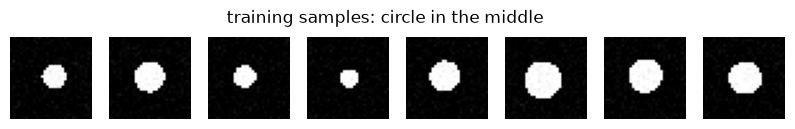

In [ ]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(0)
DEVICE = torch.device("mps")
IMG = 32
SCALES = [1, 2, 4, 8]
CODEBOOK = 64
Z_CH = 16
VAR_DIM = 64
VAR_LAYERS = 2
VAR_HEADS = 4


def make_circle_batch(B, size=IMG, device=DEVICE):
    """Mildly random centered circles on a black background."""
    ys = torch.linspace(-1, 1, size, device=device)
    xs = torch.linspace(-1, 1, size, device=device)
    yy, xx = torch.meshgrid(ys, xs, indexing="ij")
    grid = torch.stack([xx, yy], dim=0).unsqueeze(0).expand(B, -1, -1, -1)
    cx = 0.05 * torch.randn(B, 1, 1, 1, device=device)
    cy = 0.05 * torch.randn(B, 1, 1, 1, device=device)
    r = (0.35 + 0.08 * torch.randn(B, 1, 1, 1, device=device)).clamp(0.22, 0.55)
    dist = torch.sqrt((grid[:, 0:1] - cx) ** 2 + (grid[:, 1:2] - cy) ** 2)
    img = (dist < r).float()
    img = img + 0.03 * torch.randn_like(img)
    return img.clamp(0, 1)


# preview
x_preview = make_circle_batch(8).cpu()
fig, axes = plt.subplots(1, 8, figsize=(10, 1.4))
for ax, img in zip(axes, x_preview):
    ax.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.suptitle("training samples: circle in the middle")
plt.show()


## 2. Multi-scale residual VQ tokenizer

Shared codebook. Each scale quantizes the current residual, then upsamples and subtracts. Decoder sees the sum of all scale embeddings.


In [ ]:
class VectorQuantizer(nn.Module):
    """把连续特征向量换成 codebook 里最近的离散向量（查表）。"""

    def __init__(self, n_codes, dim):
        super().__init__()
        # codebook: n_codes 个可学习原型向量，每个 dim 维
        self.codebook = nn.Embedding(n_codes, dim)
        nn.init.uniform_(self.codebook.weight, -1.0 / n_codes, 1.0 / n_codes)

    def forward(self, z):
        # z: (B, C, H, W) 待量化的连续特征
        B, C, H, W = z.shape
        # 每个空间位置当成一个 C 维向量 -> (B*H*W, C)
        flat = z.permute(0, 2, 3, 1).reshape(-1, C)

        # ||a-b||^2 = ||a||^2 - 2 a·b + ||b||^2，对每个位置找最近 code
        dist = (
            flat.pow(2).sum(1, keepdim=True)
            - 2 * flat @ self.codebook.weight.t()
            + self.codebook.weight.pow(2).sum(1)
        )
        idx = dist.argmin(1)  # (B*H*W,) 离散下标

        # 查表得到量化后的连续向量，再还原成特征图 (B, C, H, W)
        q = self.codebook(idx).view(B, H, W, C).permute(0, 3, 1, 2)

        # Straight-Through: 前向用 q，反向梯度当 z→q 是恒等，让 encoder 能更新
        q_st = z + (q - z).detach()

        # VQ loss: 拉近 z 与 code（commitment）+ 拉近 code 与 z（codebook）
        commit = F.mse_loss(z, q.detach()) + 0.25 * F.mse_loss(q, z.detach())
        return q_st, idx.view(B, H, W), commit


class MultiScaleVQVAE(nn.Module):
    """多尺度残差 VQ：粗尺度先量化，细尺度量化「还没解释完」的残差。"""

    def __init__(self, scales=SCALES, z_ch=Z_CH, n_codes=CODEBOOK):
        super().__init__()
        self.scales = list(scales)  # e.g. [1, 2, 4, 8]

        # 32x32 -> 16x16 -> 8x8 latent
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, z_ch, 3, 1, 1),
        )
        # 所有尺度共用同一本 codebook
        self.vq = VectorQuantizer(n_codes, z_ch)

        # 8x8 latent -> 16x16 -> 32x32 图像
        self.decoder = nn.Sequential(
            nn.Conv2d(z_ch, 64, 3, 1, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid(),
        )

    def encode_indices(self, x):
        f = self.encoder(x)          # 连续 latent (B, C, 8, 8)
        residual = f                 # 当前还没被各尺度解释的部分
        indices, commits = [], []
        recon_f = 0.0                # 各尺度量化结果上采样后的累加

        for h in self.scales:
            # 把残差缩到本尺度网格，例如 8x8 -> 4x4
            r = F.interpolate(residual, size=(h, h), mode="area")
            # 量化：得到离散 index 网格 + 量化向量
            q, idx, commit = self.vq(r)
            # 再放大回满分辨率 latent，从残差里减掉（下一尺度只补差）
            q_up = F.interpolate(q, size=f.shape[-2:], mode="nearest")
            residual = residual - q_up
            recon_f = recon_f + q_up
            indices.append(idx)      # (B, h, h) codebook 下标
            commits.append(commit)

        return indices, recon_f, f, sum(commits) / len(commits)

    def decode_from_indices(self, indices, up_to=None):
        """只用前几个尺度的 token 重建图像（默认用全部）。"""
        if up_to is None:
            up_to = len(indices) - 1
        recon_f = 0.0
        target = self.scales[-1]  # 满 latent 边长，这里是 8
        for j in range(up_to + 1):
            idx = indices[j]
            h = self.scales[j]
            B = idx.shape[0]
            # index -> embedding -> (B, C, h, h) -> 上采样到 8x8 再累加
            q = self.vq.codebook(idx.reshape(B, -1)).transpose(1, 2).reshape(B, -1, h, h)
            recon_f = recon_f + F.interpolate(q, size=(target, target), mode="nearest")
        return self.decoder(recon_f)  # -> (B, 1, 32, 32)

    def forward(self, x):
        indices, recon_f, _, commit = self.encode_indices(x)
        x_hat = self.decoder(recon_f)
        recon = F.mse_loss(x_hat, x)           # 重建误差
        return x_hat, indices, recon + commit  # 总 loss = 重建 + VQ


vq = MultiScaleVQVAE().to(DEVICE)
opt_vq = torch.optim.Adam(vq.parameters(), lr=2e-3)

print("Training multi-scale VQ tokenizer...")
for step in range(300):
    x = make_circle_batch(32, device=DEVICE)
    _, _, loss = vq(x)
    opt_vq.zero_grad()
    loss.backward()
    opt_vq.step()
    if (step + 1) % 100 == 0:
        print(f"  step {step + 1}: loss={loss.item():.4f}")

# 冻结 tokenizer：后面只训 VAR，把它当固定「分词器」
vq.eval()
for p in vq.parameters():
    p.requires_grad_(False)
print("Tokenizer frozen.")


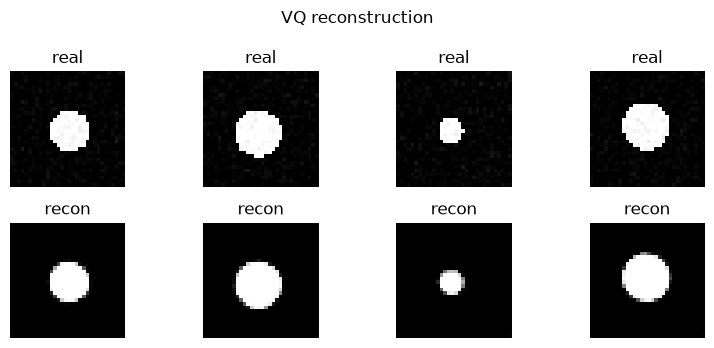

token grid shapes: [(4, 1, 1), (4, 2, 2), (4, 4, 4), (4, 8, 8)]


In [13]:
# tokenizer reconstruction check
with torch.no_grad():
    x = make_circle_batch(4, device=DEVICE)
    x_hat, indices, _ = vq(x)

fig, axes = plt.subplots(2, 4, figsize=(8, 3.5))
for i in range(4):
    axes[0, i].imshow(x[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title("real")
    axes[0, i].axis("off")
    axes[1, i].imshow(x_hat[i, 0].cpu(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("recon")
    axes[1, i].axis("off")
plt.suptitle("VQ reconstruction")
plt.tight_layout()
plt.show()

print("token grid shapes:", [tuple(z.shape) for z in indices])


## 3. Next-scale VAR

Predict each scale's token grid from all coarser scales (parallel within a scale). Queries carry only scale/position embeddings so labels cannot leak.


In [14]:
class VARTransformer(nn.Module):
    def __init__(self, scales=SCALES, n_codes=CODEBOOK, dim=VAR_DIM, layers=VAR_LAYERS, heads=VAR_HEADS):
        super().__init__()
        self.scales = list(scales)
        self.n_codes = n_codes
        self.tok_emb = nn.Embedding(n_codes, dim)
        self.scale_emb = nn.Embedding(len(scales), dim)
        max_hw = scales[-1]
        self.row_emb = nn.Embedding(max_hw, dim)
        self.col_emb = nn.Embedding(max_hw, dim)
        layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=dim * 4,
            batch_first=True, activation="gelu", norm_first=True,
        )
        self.blocks = nn.TransformerEncoder(layer, num_layers=layers)
        self.ln = nn.LayerNorm(dim)
        self.head = nn.Linear(dim, n_codes)
        self.start = nn.Parameter(torch.randn(1, 1, dim) * 0.02)

    def _embed_scale(self, idx, scale_i):
        B, H, W = idx.shape
        tok = self.tok_emb(idx)
        si = torch.full((B, H, W), scale_i, device=idx.device, dtype=torch.long)
        rows = torch.arange(H, device=idx.device).view(1, H, 1).expand(B, H, W)
        cols = torch.arange(W, device=idx.device).view(1, 1, W).expand(B, H, W)
        emb = tok + self.scale_emb(si) + self.row_emb(rows) + self.col_emb(cols)
        return emb.reshape(B, H * W, -1)

    def _queries(self, B, scale_i, H, W, device):
        si = torch.full((B, H, W), scale_i, device=device, dtype=torch.long)
        rows = torch.arange(H, device=device).view(1, H, 1).expand(B, H, W)
        cols = torch.arange(W, device=device).view(1, 1, W).expand(B, H, W)
        q = self.scale_emb(si) + self.row_emb(rows) + self.col_emb(cols)
        return q.reshape(B, H * W, -1)

    def forward(self, indices_list):
        B = indices_list[0].shape[0]
        device = indices_list[0].device
        prefix = self.start.expand(B, -1, -1)
        total = 0.0
        for k, h in enumerate(self.scales):
            queries = self._queries(B, k, h, h, device)
            out = self.blocks(torch.cat([prefix, queries], dim=1))
            logits = self.head(self.ln(out[:, -h * h :]))
            target = indices_list[k].reshape(B, -1)
            total = total + F.cross_entropy(
                logits.reshape(-1, self.n_codes), target.reshape(-1)
            )
            prefix = torch.cat([prefix, self._embed_scale(indices_list[k], k)], dim=1)
        return total / len(self.scales)

    @torch.no_grad()
    def sample(self, B=4, temperature=1.0):
        device = self.start.device
        prefix = self.start.expand(B, -1, -1)
        indices = []
        for k, h in enumerate(self.scales):
            queries = self._queries(B, k, h, h, device)
            out = self.blocks(torch.cat([prefix, queries], dim=1))
            logits = self.head(self.ln(out[:, -h * h :])) / max(temperature, 1e-6)
            probs = F.softmax(logits, dim=-1)
            idx = torch.multinomial(probs.reshape(B * h * h, -1), 1).view(B, h, h)
            indices.append(idx)
            prefix = torch.cat([prefix, self._embed_scale(idx, k)], dim=1)
        return indices


var = VARTransformer().to(DEVICE)
opt_var = torch.optim.Adam(var.parameters(), lr=2e-3)

print("Training next-scale VAR...")
for step in range(400):
    x = make_circle_batch(32, device=DEVICE)
    with torch.no_grad():
        indices, _, _, _ = vq.encode_indices(x)
    loss = var(indices)
    opt_var.zero_grad()
    loss.backward()
    opt_var.step()
    if (step + 1) % 100 == 0:
        print(f"  step {step + 1}: loss={loss.item():.4f}")
print("Done.")


Training next-scale VAR...


/var/folders/6g/9chj8ddx1033kwmzkbfd95l40000gn/T/ipykernel_4066/2259260557.py:15: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(layer, num_layers=layers)


  step 100: loss=1.3714
  step 200: loss=1.0649
  step 300: loss=1.0485
  step 400: loss=0.9466
Done.


## 4. Sample and visualize coarse → fine

**Important:** `after 4x4` does **not** mean the image is 4×4 pixels.

- Token grid at that scale is `4×4` (discrete codes).
- Decoder always maps the summed latent back to full **`32×32`** images.
- So every column was 32×32; later scales only add residual detail.

Below we show both:
1. full `32×32` decode using tokens up to each scale
2. **native-looking sizes**: nearest-downsample to `token_h * 4` (because `32/8=4`), so `1→4px, 2→8px, 4→16px, 8→32px` — different resolutions side by side.


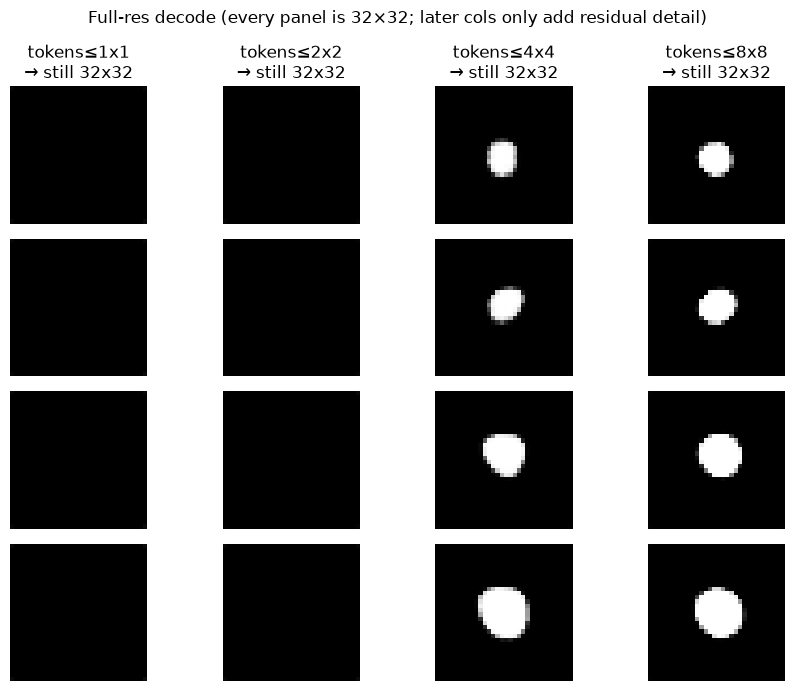

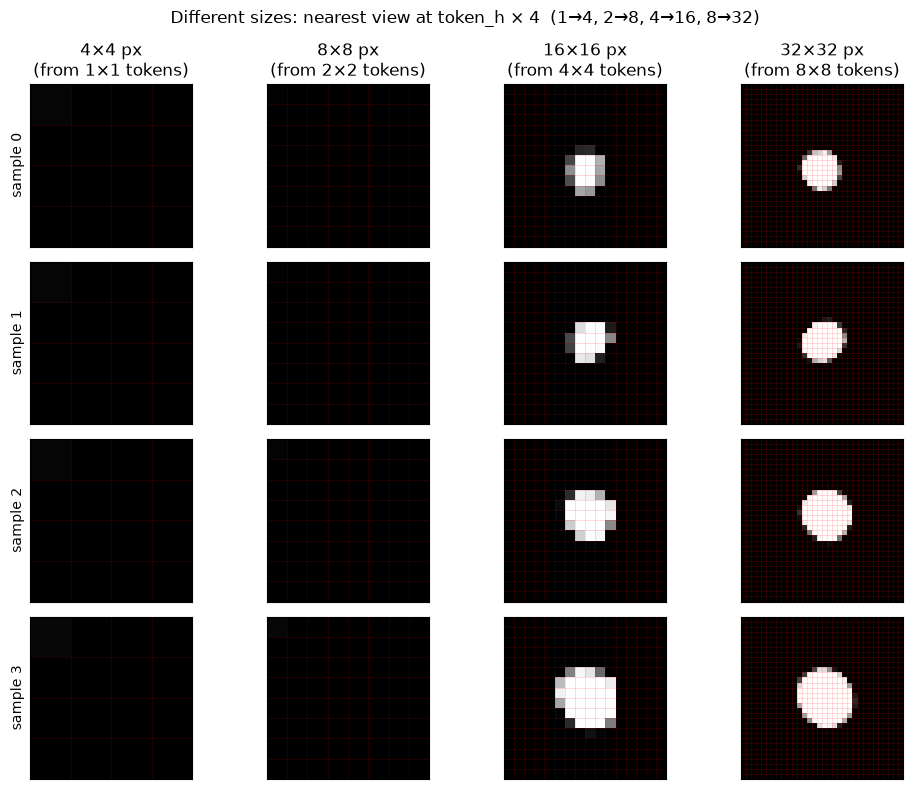

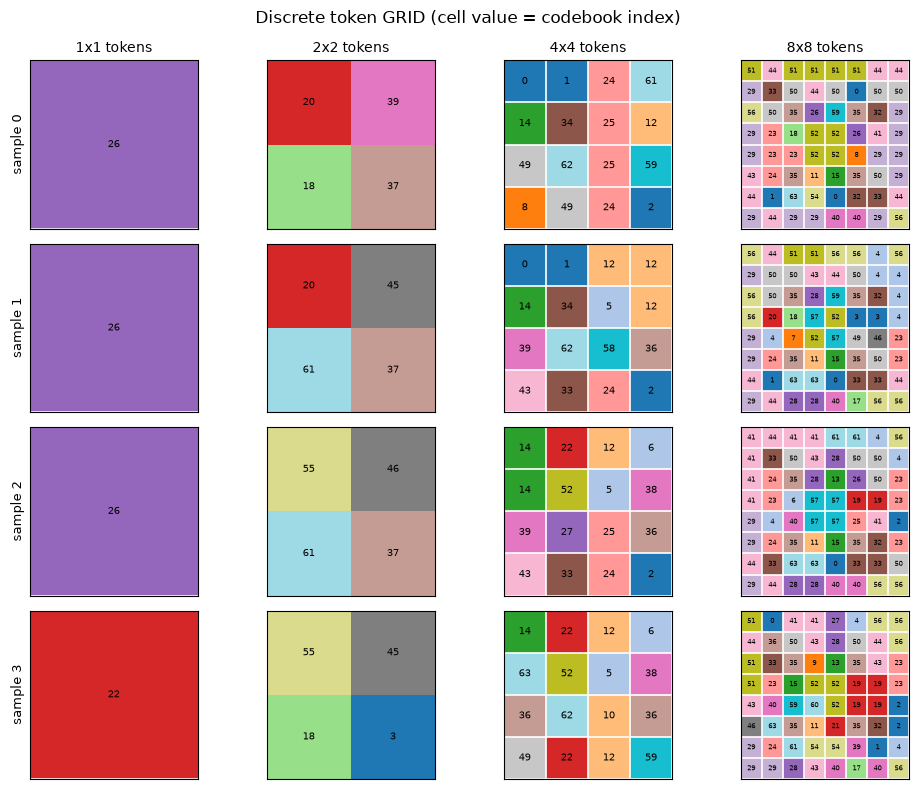

In [15]:
var.eval()
N_SHOW = 4
PIXELS_PER_LATENT = IMG // SCALES[-1]  # 32/8 = 4


def draw_token_grid(ax, idx_hw, title=None):
    """Paint codebook indices as an HxW grid with cell borders + index labels."""
    grid = idx_hw.detach().cpu().numpy()
    H, W = grid.shape
    ax.imshow(grid, cmap="tab20", vmin=0, vmax=max(CODEBOOK - 1, 1), interpolation="nearest")
    ax.set_xticks([i - 0.5 for i in range(W + 1)], minor=True)
    ax.set_yticks([i - 0.5 for i in range(H + 1)], minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1.2)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
    for i in range(H):
        for j in range(W):
            ax.text(j, i, str(int(grid[i, j])), ha="center", va="center",
                    fontsize=7 if H <= 4 else 5, color="black")
    if title:
        ax.set_title(title, fontsize=10)


with torch.no_grad():
    gen_idx = var.sample(B=N_SHOW, temperature=0.8)
    # always full-res 32x32 decode, using only scales 0..k
    stages_full = [vq.decode_from_indices(gen_idx, up_to=k) for k in range(len(SCALES))]
    # view at "information resolution" for that scale: (h * 4) x (h * 4)
    stages_native = []
    for k, h in enumerate(SCALES):
        side = h * PIXELS_PER_LATENT
        stages_native.append(
            F.interpolate(stages_full[k], size=(side, side), mode="nearest")
        )

# 1) same canvas size (all 32x32) — can look misleading
fig, axes = plt.subplots(N_SHOW, len(SCALES), figsize=(9, 7))
for r in range(N_SHOW):
    for c, h in enumerate(SCALES):
        axes[r, c].imshow(stages_full[c][r, 0].cpu(), cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axes[r, c].axis("off")
        if r == 0:
            axes[r, c].set_title(f"tokens≤{h}x{h}\n→ still {IMG}x{IMG}")
plt.suptitle("Full-res decode (every panel is 32×32; later cols only add residual detail)")
plt.tight_layout()
plt.show()

# 2) true different sizes — what you probably wanted
fig, axes = plt.subplots(N_SHOW, len(SCALES), figsize=(10, 8))
for r in range(N_SHOW):
    for c, h in enumerate(SCALES):
        img = stages_native[c][r, 0].cpu()
        side = h * PIXELS_PER_LATENT
        axes[r, c].imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        axes[r, c].set_xlim(-0.5, side - 0.5)
        axes[r, c].set_ylim(side - 0.5, -0.5)
        axes[r, c].set_xticks([i - 0.5 for i in range(side + 1)], minor=True)
        axes[r, c].set_yticks([i - 0.5 for i in range(side + 1)], minor=True)
        axes[r, c].grid(which="minor", color="red", alpha=0.25, linewidth=0.4)
        axes[r, c].tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)
        axes[r, c].set_aspect("equal")
        if r == 0:
            axes[r, c].set_title(f"{side}×{side} px\n(from {h}×{h} tokens)")
        if c == 0:
            axes[r, c].set_ylabel(f"sample {r}")
plt.suptitle("Different sizes: nearest view at token_h × 4  (1→4, 2→8, 4→16, 8→32)")
plt.tight_layout()
plt.show()

# 3) token index grids
fig, axes = plt.subplots(N_SHOW, len(SCALES), figsize=(10, 8))
for r in range(N_SHOW):
    for c, h in enumerate(SCALES):
        title = f"{h}x{h} tokens" if r == 0 else None
        draw_token_grid(axes[r, c], gen_idx[c][r], title=title)
        if c == 0:
            axes[r, c].set_ylabel(f"sample {r}", fontsize=9)
plt.suptitle("Discrete token GRID (cell value = codebook index)")
plt.tight_layout()
plt.show()
